Accuratezza del modello:  100.00%

Classification Report: 
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Confusion Matrix: 
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

 Importanza delle feature:
petal width (cm)     0.433982
petal length (cm)    0.417308
sepal length (cm)    0.104105
sepal width (cm)     0.044605
dtype: float64


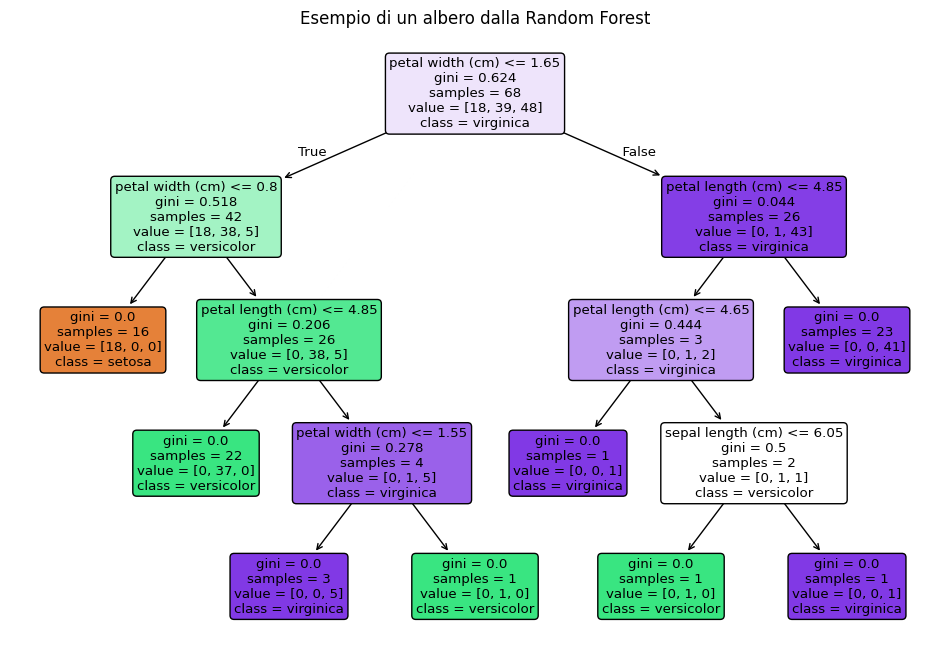

In [5]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1 Caricare i dati
iris = load_iris()
X = iris.data
y = iris.target

# 2. Dividere i dati in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Creare il modello
# n_estimators = 100 significa che costruiremo uno foresta di 100 alberi
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. addestrare il modello
clf.fit(X_train, y_train)

# 5. Fare previsioni sul testi di test
y_pred = clf.predict(X_test)

# 6. Valutare l'accuratezza
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuratezza del modello: {accuracy * 100: .2f}%")
print("\nClassification Report: \n", classification_report(y_test, y_pred, target_names=iris.target_names))
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))

# 7. COntrollare l'importanza delle feature.
feature_imp = pd.Series(clf.feature_importances_, index=iris.feature_names).sort_values(ascending=False)
print("\n Importanza delle feature:")
print(feature_imp)

# Visualizzare uno degli alberi della foresta (ad esempio il primo)
plt.figure(figsize=(12,8))
plot_tree(clf.estimators_[0],
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True)
plt.title("Esempio di un albero dalla Random Forest")
plt.show()